# **Домашнее задание 1: Оптический поток и динамика видео**

### **Цель**

Освоить практическое применение оптического потока для анализа движения, научиться строить полные видеопайплайны, включающие вычисление потока, фильтрацию, warping и стабилизацию. Студент выбирает **одну** из двух инженерных задач: построение мини-системы **стабилизации камеры** или создание **трекинг-модуля движения**, анализирующего траектории и устойчивость методов Lucas–Kanade и Farnebäck.

# **Вариант B: Учебная система анализа движения (трекинг-модуль)**

### **Задание**

1. Выбрать любой видеоролик с несколькими движущимися объектами.
2. Реализовать вычисление разреженного оптического потока (Lucas–Kanade) и плотного (Farnebäck).
3. Для LK:
   – найти ключевые точки;
   – отследить траектории по 50–200 кадрам;
   – визуализировать движение в координатной системе кадра.
4. Для Farnebäck:
   – построить поле движения;
   – выделить движущиеся объекты через модуль потока;
   – получить бинарные маски движения.
5. Сравнить чувствительность методов к текстуре, motion blur, теням, шуму.
6. Провести **качественный и количественный разбор ошибок**: где LK теряет точки, где плотный поток выдаёт шум, где маска движения фрагментируется.
7. Подготовить краткое исследование: по каким признакам студент выбирал бы LK или Farnebäck в реальной задаче.


## Импорт библиотек

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Загрузка видео

In [2]:
video_path = '/Users/leodanilov/Downloads/motion_cv.mp4'
cap = cv2.VideoCapture(video_path)

ret, first_frame = cap.read()
gray_prev = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)

## Лукас-Канаде

In [3]:
feature_params = dict(maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)
lk_params = dict(winSize=(15, 15), maxLevel=2, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

p0 = cv2.goodFeaturesToTrack(gray_prev, mask=None, **feature_params)
trajectories = {i: [p0[i].ravel()] for i in range(len(p0))}
point_ids = list(range(len(p0)))
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

for i in range(200):
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    p1, st, err = cv2.calcOpticalFlowPyrLK(gray_prev, gray, p0, None, **lk_params)
    
    if p1 is not None:
        good_new = p1[st == 1]
        good_ids = [point_ids[j] for j in range(len(st)) if st[j]]
        
        for idx, point in zip(good_ids, good_new):
            trajectories[idx].append(point.ravel())
        
        point_ids = good_ids
        p0 = good_new.reshape(-1, 1, 2)
    
    gray_prev = gray.copy()

cap.release()

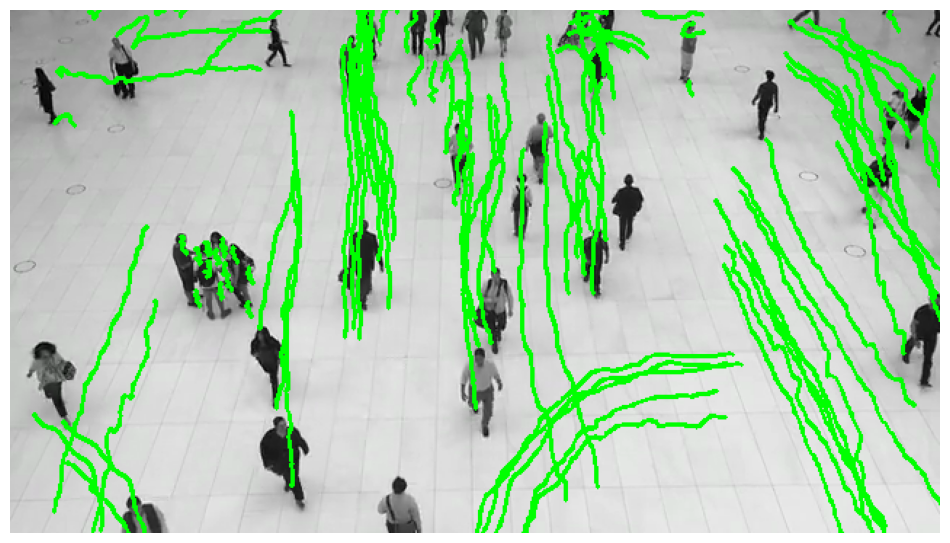

In [4]:
# Visualize LK trajectories
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 199)
ret, vis_frame = cap.read()

for point_id, traj in trajectories.items():
    for i in range(len(traj) - 1):
        pt1 = tuple(traj[i].astype(int))
        pt2 = tuple(traj[i + 1].astype(int))
        cv2.line(vis_frame, pt1, pt2, (0, 255, 0), 2)

cap.release()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Фарнебэк

In [5]:
# Farneback dense flow
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret, frame1 = cap.read()
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

ret, frame2 = cap.read()
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

flow = cv2.calcOpticalFlowFarneback(gray1, gray2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

cap.release()

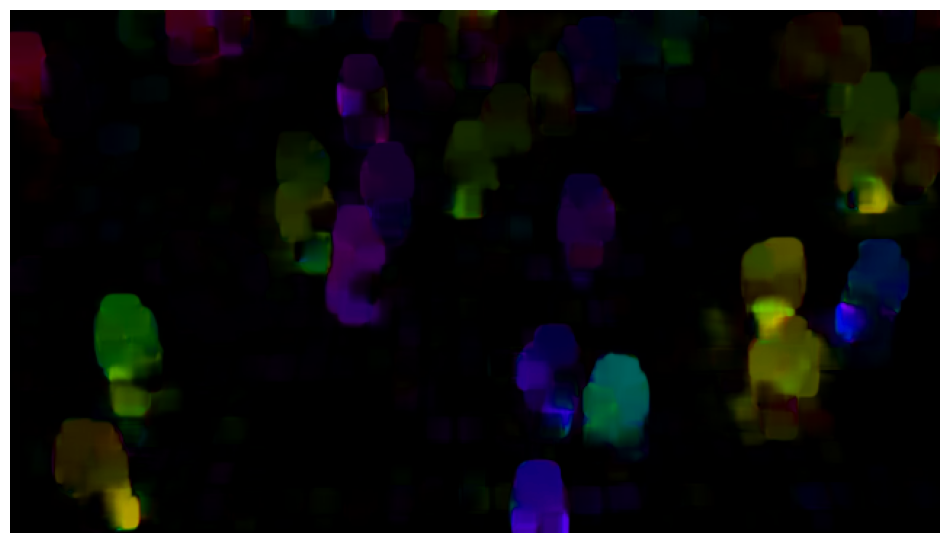

In [6]:
# Visualize dense flow
hsv = np.zeros_like(frame1)
hsv[..., 1] = 255
hsv[..., 0] = angle * 180 / np.pi / 2
hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
rgb_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(rgb_flow, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Бинарная маска движения

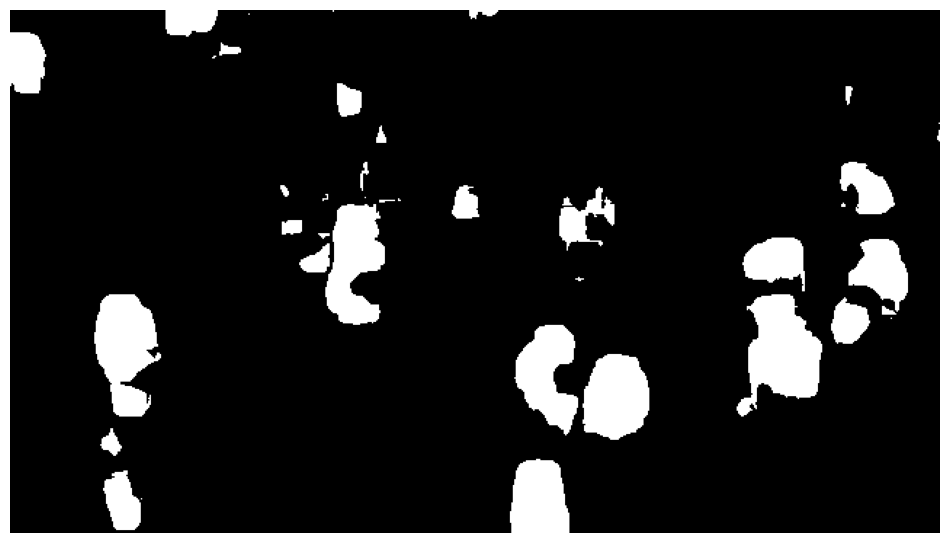

In [11]:
# Binary motion mask
threshold = 0.9
motion_mask = (magnitude > threshold).astype(np.uint8) * 255

plt.figure(figsize=(12, 8))
plt.imshow(motion_mask, cmap='gray')
plt.axis('off')
plt.show()

## Сравнение методов Lucas-Kanade и Farneback

### Различия:

**Lucas-Kanade (sparse):**
- Плюсы: Работает быстро, точно отслежтвает конкретные фичи
- Минусы: Со временем теряет точки, нуждается в хорошей текстуре
- Сбой возникает, при: Области с низкой текстурой, перекрытия, объекты выходят за пределы кадра

**Farneback (dense):**
- Плюсы: Полное поле движения, обнаруживает все движущиеся области
- Минусы: Шум в областях с низкой текстурой, требует больших вычислительных затрат
- Сбой при: однородных областях, тенях, изменении освещения

### Когда использовать:

**LK когда:**
- Необходимо отслеживать определенные объекты / особенности
- Важна скорость
- Есть четкие ключевые точки

**Farneback когда:**
- Требуется полный анализ движения сцены
- Обнаружение всех движущихся объектов
- Требуется сегментация движения

In [8]:
# Error Analysis: Farneback noise and fragmentation
noise_pixels = np.sum((magnitude > 0) & (magnitude < threshold))
motion_pixels = np.sum(magnitude > threshold)
total_pixels = magnitude.size

print(f"Total pixels: {total_pixels}")
print(f"Motion pixels (>{threshold}): {motion_pixels} ({motion_pixels/total_pixels*100:.1f}%)")
print(f"Noise pixels (0-{threshold}): {noise_pixels} ({noise_pixels/total_pixels*100:.1f}%)")
print(f"Flow magnitude: min={magnitude.min():.2f}, max={magnitude.max():.2f}, mean={magnitude.mean():.2f}")

# Count fragments in binary mask
num_labels, labels = cv2.connectedComponents(motion_mask)
print(f"Number of separate motion regions (fragments): {num_labels - 1}")

Total pixels: 230400
Motion pixels (>2.0): 3652 (1.6%)
Noise pixels (0-2.0): 226748 (98.4%)
Flow magnitude: min=0.00, max=4.52, mean=0.27
Number of separate motion regions (fragments): 13


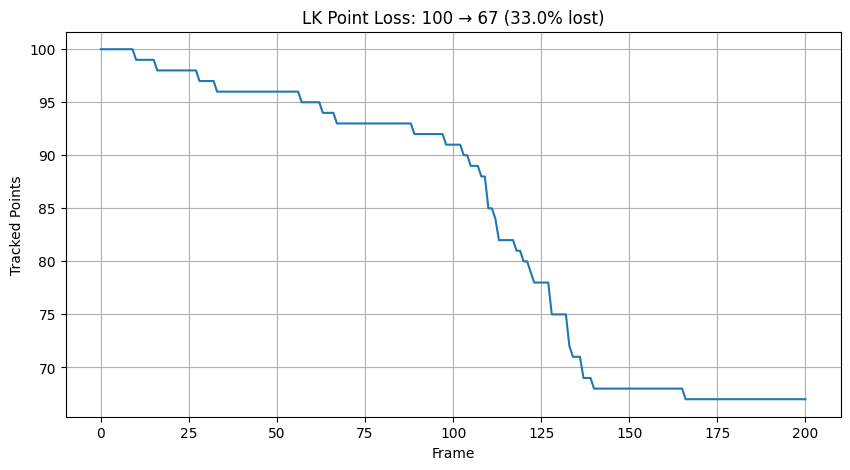

Initial points: 100
Final points: 67
Loss rate: 33.0%


In [9]:
# Error Analysis: LK point loss over time
max_frames = max(len(traj) for traj in trajectories.values())
point_counts = []
for frame_idx in range(max_frames):
    count = sum(1 for traj in trajectories.values() if len(traj) > frame_idx)
    point_counts.append(count)

initial_points = point_counts[0]
final_points = point_counts[-1]
loss_rate = (initial_points - final_points) / initial_points * 100

plt.figure(figsize=(10, 5))
plt.plot(point_counts)
plt.xlabel('Frame')
plt.ylabel('Tracked Points')
plt.title(f'LK Point Loss: {initial_points} → {final_points} ({loss_rate:.1f}% lost)')
plt.grid(True)
plt.show()

print(f"Initial points: {initial_points}")
print(f"Final points: {final_points}")
print(f"Loss rate: {loss_rate:.1f}%")

# **Требования к сдаче**

Репозиторий на GitHub:

* `src/` или ноутбук с кодом вычисления оптического потока и всего пайплайна.
* `README.md` c описанием выбранного варианта (A или B), параметров, применённых фильтров и основных наблюдений.
* Визуализации:
  – для варианта A: примерные кадры «до/после», графики траектории движения камеры, примеры warping-а;
  – для варианта B: траектории LK, карты плотного потока, маски движения.
* При варианте A — итоговое стабилизированное видео.
* При варианте B — сравнительный отчёт о различиях LK и Farnebäck.

# **Критерии оценки**

| Баллы | Критерий                                                                      |
| ----- | ----------------------------------------------------------------------------- |
| 0–3   | Полнота: реализованы все этапы выбранного варианта (A или B).                 |
| 0–3   | Код: чистый, воспроизводимый, корректно использует OpenCV.                    |
| 0–2   | Анализ: качественный разбор ошибок, интерпретация результатов, выводы.        |
| 0–2   | Репозиторий: аккуратность, читаемость, примеры визуализаций, понятный README. |

**Максимум: 10 баллов.**